<a href="https://colab.research.google.com/github/kartavya-ss/Customer_churn_shap/blob/main/Customer_churn_shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

# List the contents of the downloaded directory to find the CSV file
print("Contents of the dataset directory:")
for item in os.listdir(path):
    print(f"- {item}")

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn
Contents of the dataset directory:
- WA_Fn-UseC_-Telco-Customer-Churn.csv


In [52]:
!pip install pandas numpy scikit-learn xgboost imbalanced-learn matplotlib seaborn

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import pickle

In [54]:
import os

df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))

print("Shape of data:", df.shape)
df.head()

Shape of data: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


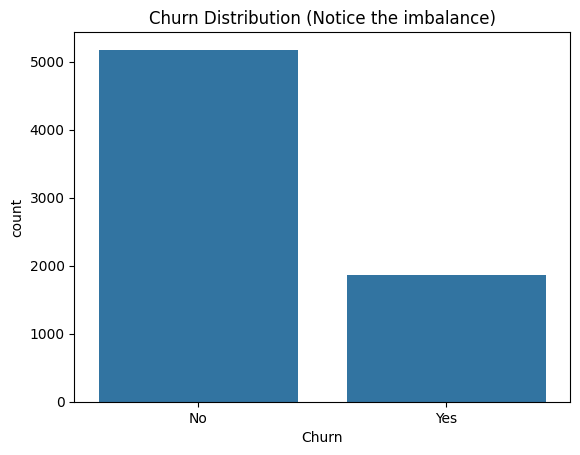

In [55]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution (Notice the imbalance)")
plt.show()

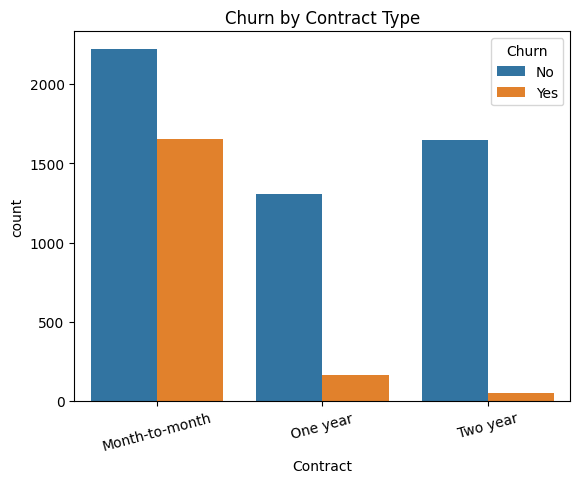

In [56]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

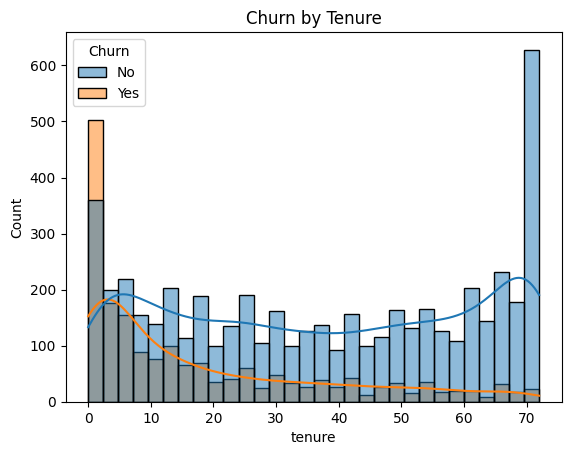

In [57]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Churn by Tenure")
plt.show()

In [58]:
# TotalCharges sometimes has blank strings instead of NaN — fix that
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop customerID — it's just an identifier, no predictive value
df.drop('customerID', axis=1, inplace=True)

# Convert target column to 0/1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [59]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [60]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (5634, 19) Test shape: (1409, 19)


In [61]:
# CONCEPT:
# Our data is ~73% "No churn" and ~27% "Churn".
# A model trained directly on this tends to just predict "No churn" a lot,
# since that's the easier, more common pattern — leading to poor recall on
# churners specifically, which is exactly who we care about catching.

neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

scale_pos_weight = 2.77


In [62]:
# from imblearn.over_sampling import SMOTE
# smote = SMOTE(random_state=42)
# X_train, y_train = smote.fit_resample(X_train, y_train)

In [63]:
print("Before SMOTE:", np.bincount(y_train))

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train_sm))

Before SMOTE: [4139 1495]
After SMOTE: [4139 4139]


In [64]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

In [65]:
results = {}

In [66]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_sm)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_pred = lr.predict(X_test_scaled)

results['Logistic Regression'] = {
    'AUC': roc_auc_score(y_test, lr_proba),
    'Precision': precision_score(y_test, lr_pred),
    'Recall': recall_score(y_test, lr_pred),
    'F1': f1_score(y_test, lr_pred)
}
print(results['Logistic Regression'])

{'AUC': np.float64(0.8222144720865947), 'Precision': 0.5234375, 'Recall': 0.7165775401069518, 'F1': 0.6049661399548533}


In [67]:
rf = RandomForestClassifier(random_state=42, n_estimators=200)
rf.fit(X_train_sm, y_train_sm)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

results['Random Forest'] = {
    'AUC': roc_auc_score(y_test, rf_proba),
    'Precision': precision_score(y_test, rf_pred),
    'Recall': recall_score(y_test, rf_pred),
    'F1': f1_score(y_test, rf_pred)
}
print(results['Random Forest'])

{'AUC': np.float64(0.8237141233304914), 'Precision': 0.5755968169761273, 'Recall': 0.5802139037433155, 'F1': 0.5778961384820239}


In [68]:
xgb_model = xgb.XGBClassifier(eval_metric='auc', random_state=42, use_label_encoder=False)
xgb_model.fit(X_train_sm, y_train_sm)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)

results['XGBoost'] = {
    'AUC': roc_auc_score(y_test, xgb_proba),
    'Precision': precision_score(y_test, xgb_pred),
    'Recall': recall_score(y_test, xgb_pred),
    'F1': f1_score(y_test, xgb_pred)
}
print(results['XGBoost'])

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [23:04:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'AUC': np.float64(0.8119817096799196), 'Precision': 0.5604938271604938, 'Recall': 0.606951871657754, 'F1': 0.582798459563543}


In [69]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values('AUC', ascending=False)
print(comparison_df)

                          AUC  Precision    Recall        F1
Random Forest        0.823714   0.575597  0.580214  0.577896
Logistic Regression  0.822214   0.523438  0.716578  0.604966
XGBoost              0.811982   0.560494  0.606952  0.582798


In [70]:
param_grid_rf = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid_rf,
    n_iter=25,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)
random_search_rf.fit(X_train_sm, y_train_sm)
print("Best RF params:", random_search_rf.best_params_)
best_model = random_search_rf.best_estimator_

Best RF params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}


In [71]:
final_proba = best_model.predict_proba(X_test)[:, 1]
final_pred = best_model.predict(X_test)

print("Tuned Model Performance:")
print(f"AUC-ROC:   {roc_auc_score(y_test, final_proba):.3f}")
print(f"Precision: {precision_score(y_test, final_pred):.3f}")
print(f"Recall:    {recall_score(y_test, final_pred):.3f}")
print(f"F1 Score:  {f1_score(y_test, final_pred):.3f}")
print("\n", classification_report(y_test, final_pred))

Tuned Model Performance:
AUC-ROC:   0.825
Precision: 0.588
Recall:    0.618
F1 Score:  0.602

               precision    recall  f1-score   support

           0       0.86      0.84      0.85      1035
           1       0.59      0.62      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.73      1409
weighted avg       0.79      0.78      0.79      1409



In [72]:
with open('churn_model_final.pkl', 'wb') as f:
    pickle.dump(best_model, f)

X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
X_train_sm.to_csv('X_train_sm.csv', index=False)
comparison_df.to_csv('model_comparison.csv')

print("Saved: churn_model_final.pkl, X_test.csv, y_test.csv, X_train_sm.csv, model_comparison.csv")
print("Ready for Day 2: SHAP explainability")

Saved: churn_model_final.pkl, X_test.csv, y_test.csv, X_train_sm.csv, model_comparison.csv
Ready for Day 2: SHAP explainability


In [73]:
#pip install shap

In [74]:
import pickle
import shap
import matplotlib.pyplot as plt

In [75]:
with open('churn_model_final.pkl', 'rb') as f:
    model = pickle.load(f)

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').squeeze()  # squeeze turns 1-column df into a series

print("Model loaded:", model)
print("X_test shape:", X_test.shape)

Model loaded: RandomForestClassifier(max_depth=20, n_estimators=200, random_state=42)
X_test shape: (1409, 19)


In [76]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (1409, 19, 2)


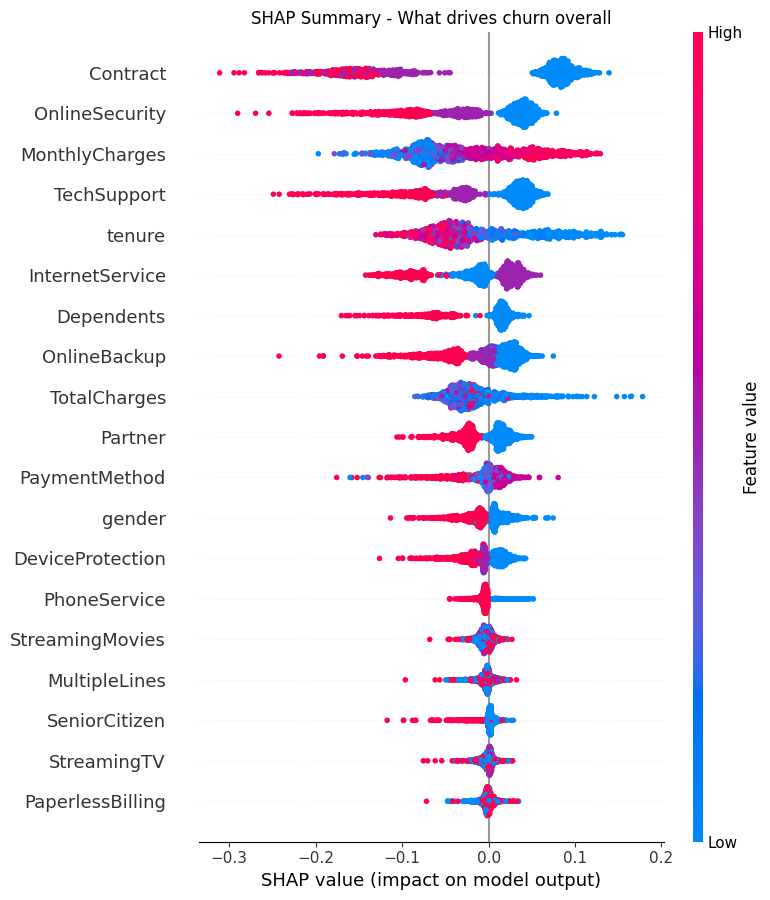

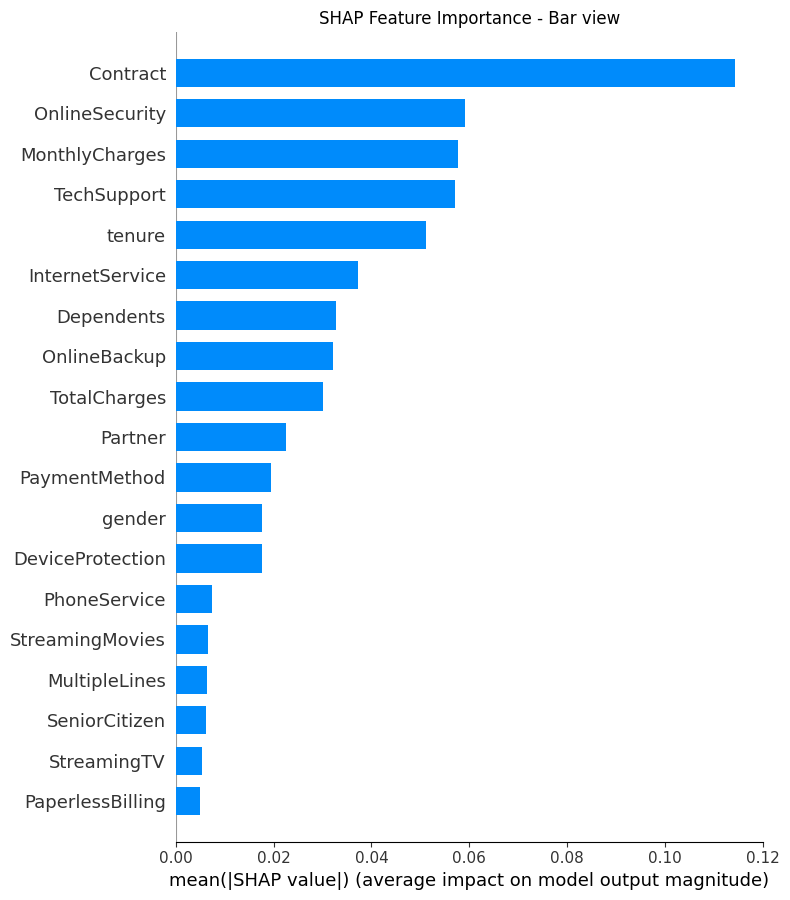

In [77]:
# ---- STEP 5 (FIXED): GLOBAL explanation ----
shap.summary_plot(shap_values[:,:,1], X_test, plot_type="dot", show=False)
plt.title("SHAP Summary - What drives churn overall")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values[:,:,1], X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance - Bar view")
plt.tight_layout()
plt.show()

In [78]:
churn_probs = model.predict_proba(X_test)[:, 1]
high_risk_idx = np.argmax(churn_probs)  # index of the highest-risk customer

print(f"Customer at index {high_risk_idx} has churn probability: {churn_probs[high_risk_idx]:.2f}")
print("\nTheir feature values:")
print(X_test.iloc[high_risk_idx])

Customer at index 1178 has churn probability: 1.00

Their feature values:
gender               1.00
SeniorCitizen        0.00
Partner              0.00
Dependents           0.00
tenure               1.00
PhoneService         0.00
MultipleLines        1.00
InternetService      0.00
OnlineSecurity       0.00
OnlineBackup         0.00
DeviceProtection     0.00
TechSupport          0.00
StreamingTV          0.00
StreamingMovies      2.00
Contract             0.00
PaperlessBilling     1.00
PaymentMethod        2.00
MonthlyCharges      35.55
TotalCharges        35.55
Name: 1178, dtype: float64


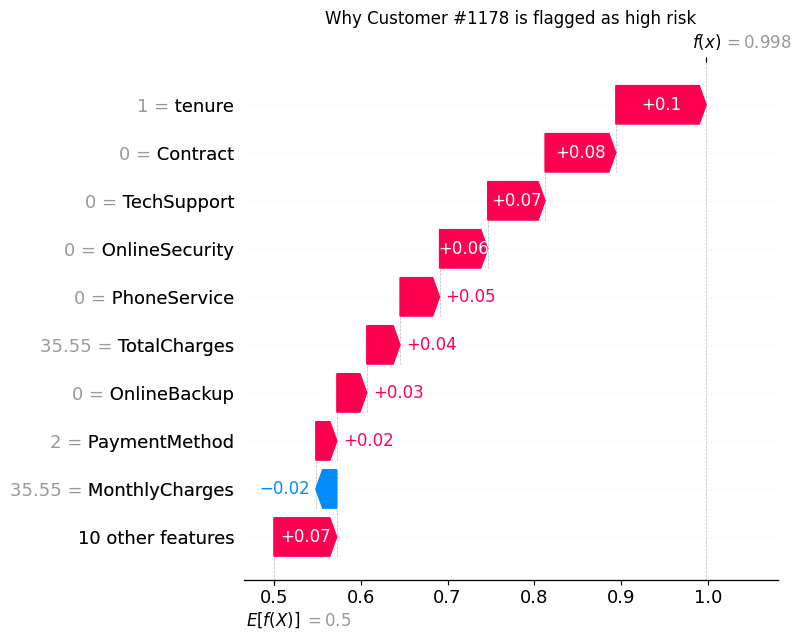

In [79]:
import shap
import matplotlib.pyplot as plt

# ---- STEP 7 (FIXED): Waterfall plot ----
explanation = shap.Explanation(
    values=shap_values[high_risk_idx, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[high_risk_idx],
    feature_names=X_test.columns.tolist()
)

shap.waterfall_plot(explanation, show=False)
plt.title(f"Why Customer #{high_risk_idx} is flagged as high risk")
plt.tight_layout()
plt.show()

Customer #10 — Churn Probability: 35.00%


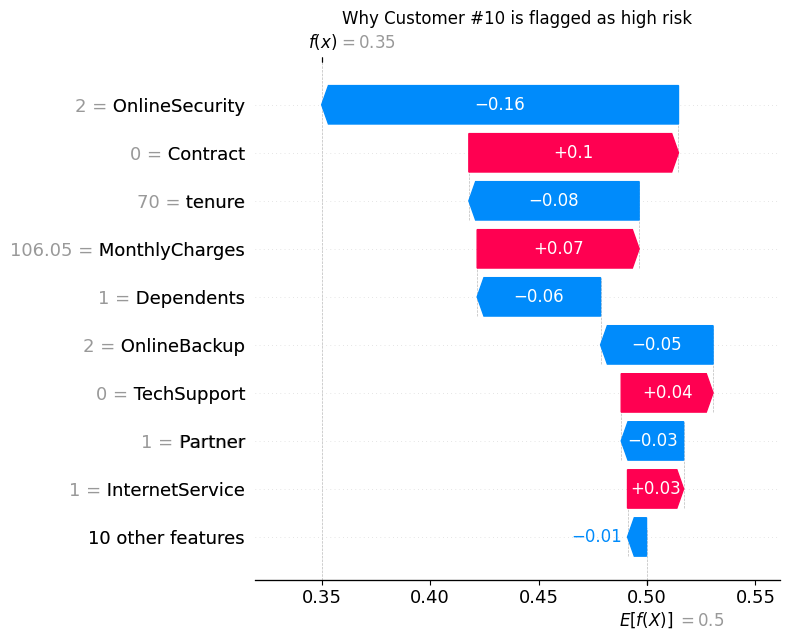

In [80]:
def explain_customer(idx):
    """
    Given a row index from X_test, prints churn probability and shows
    a SHAP waterfall plot explaining why the model made that prediction.
    """
    prob = model.predict_proba(X_test.iloc[[idx]])[:, 1][0]
    print(f"Customer #{idx} — Churn Probability: {prob:.2%}")

    explanation = shap.Explanation(
        values=shap_values[idx, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[idx],
        feature_names=X_test.columns.tolist()
    )
    shap.waterfall_plot(explanation, show=False)
    plt.title(f"Why Customer #{idx} is flagged as high risk")
    plt.tight_layout()
    plt.show()

# Try it on a random customer
explain_customer(10)

In [81]:
with open('shap_values.pkl', 'wb') as f:
    pickle.dump(shap_values, f)

with open('explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

print("Saved shap_values.pkl and explainer.pkl")


Saved shap_values.pkl and explainer.pkl
